In [15]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file in [
            "ssd_mobilenet_v3_large_coco_2020_01_14.pbtxt",
            "frozen_inference_graph.pb"
        ]:
            print(os.path.join(root, file))

/content/ssd_model/ssd_mobilenet_v3_large_coco_2020_01_14.pbtxt
/content/ssd_model/ssd_mobilenet_v3_large_coco_2020_01_14/frozen_inference_graph.pb


In [17]:
from google.colab import files

uploaded = files.upload()

Saving Screenshot 2026-09-29 140937.png to Screenshot 2026-09-29 140937.png


Configuration: /content/ssd_model/ssd_mobilenet_v3_large_coco_2020_01_14.pbtxt
Weights: /content/ssd_model/ssd_mobilenet_v3_large_coco_2020_01_14/frozen_inference_graph.pb


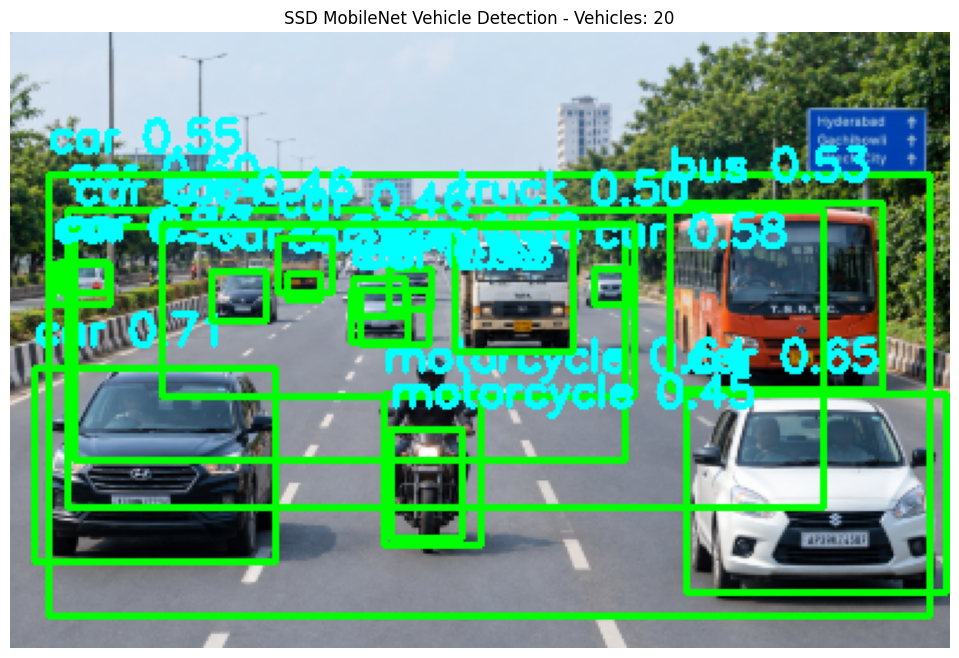

Total vehicles detected: 20


In [18]:

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

CONFIG = None
WEIGHTS = None

for root, dirs, filenames in os.walk("/content"):
    for filename in filenames:
        path = os.path.join(root, filename)

        if filename == "ssd_mobilenet_v3_large_coco_2020_01_14.pbtxt":
            CONFIG = path

        if filename == "frozen_inference_graph.pb":
            WEIGHTS = path

if CONFIG is None or WEIGHTS is None:
    raise FileNotFoundError(
        "Model files missing. Run Step 2 and check the output."
    )

print("Configuration:", CONFIG)
print("Weights:", WEIGHTS)

net = cv2.dnn_DetectionModel(WEIGHTS, CONFIG)
net.setInputSize(320, 320)
net.setInputScale(1.0 / 127.5)
net.setInputMean((127.5, 127.5, 127.5))
net.setInputSwapRB(True)

image_files = [
    f for f in os.listdir("/content")
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
    and f != "sample_data"
]

if not image_files:
    uploaded = files.upload()
    image_files = list(uploaded.keys())

image_path = os.path.join("/content", image_files[0])
image = cv2.imread(image_path)

if image is None:
    raise ValueError("Could not read the uploaded image.")

classNames = [
    "background", "person", "bicycle", "car", "motorcycle",
    "airplane", "bus", "train", "truck", "boat", "traffic light",
    "fire hydrant", "stop sign", "parking meter", "bench", "bird",
    "cat", "dog", "horse", "sheep", "cow", "elephant", "bear",
    "zebra", "giraffe", "backpack", "umbrella", "handbag", "tie",
    "suitcase", "frisbee", "skis", "snowboard", "sports ball",
    "kite", "baseball bat", "baseball glove", "skateboard",
    "surfboard", "tennis racket", "bottle", "wine glass", "cup",
    "fork", "knife", "spoon", "bowl", "banana", "apple",
    "sandwich", "orange", "broccoli", "carrot", "hot dog", "pizza",
    "donut", "cake", "chair", "couch", "potted plant", "bed",
    "dining table", "toilet", "tv", "laptop", "mouse", "remote",
    "keyboard", "cell phone", "microwave", "oven", "toaster",
    "sink", "refrigerator", "book", "clock", "vase", "scissors",
    "teddy bear", "hair drier", "toothbrush"
]

classIds, scores, boxes = net.detect(
    image,
    confThreshold=0.45,
    nmsThreshold=0.40
)

vehicle_names = {"car", "motorcycle", "bus", "truck"}
output = image.copy()
count = 0

if classIds is not None and len(classIds) > 0:
    for classId, score, box in zip(
        np.array(classIds).flatten(),
        np.array(scores).flatten(),
        boxes
    ):
        classId = int(classId)

        if 0 <= classId < len(classNames):
            name = classNames[classId]

            if name in vehicle_names:
                x, y, w, h = map(int, box)

                cv2.rectangle(
                    output, (x, y), (x + w, y + h),
                    (0, 255, 0), 2
                )

                cv2.putText(
                    output, f"{name} {score:.2f}",
                    (x, max(y - 10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                    (255, 255, 0), 2
                )
                count += 1

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title(f"SSD MobileNet Vehicle Detection - Vehicles: {count}")
plt.axis("off")
plt.show()

print("Total vehicles detected:", count)